# Autoencoder — Visual Experiments

> **Goal:** Build geometric intuition for the autoencoder through experiments — not just equations.

## What we'll explore

| # | Experiment | Question answered |
|---|---|---|
| 1 | **Bottleneck Compression** | How does latent dimension size affect reconstruction quality? |
| 2 | **Encoder → Latent → Decoder Pipeline** | What exactly happens at each stage of an AE? |
| 3 | **Latent Space Learns Generative Factors** | What structure emerges in the learned latent space? |
| 4 | **Latent Gaps** | Why can't a vanilla AE generate new data? |

---
**Linked theory:** [research/02-autoencoder.md](../research/02-autoencoder.md)  ·  **Chạy:** `uv run jupyter lab` từ thư mục `latent-anything-theory/` (cần các package trong `pyproject.toml`).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA
from sklearn.datasets import make_moons
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.35,
})
print('Setup complete. NumPy:', np.__version__)

Setup complete. NumPy: 2.4.6


---
## Experiment 1: The Bottleneck Effect

**Question:** How does the bottleneck dimension control what the AE is forced to learn?

The autoencoder compresses input $x \in \mathbb{R}^D$ into a latent code $z \in \mathbb{R}^k$ where $k \ll D$. When $k$ is smaller than the true intrinsic dimension of the data, information is irreversibly lost. When $k$ equals the true intrinsic dimension, the AE has just enough capacity to capture all structure with minimal redundancy.

We simulate this using PCA — the optimal *linear* autoencoder under MSE loss — on 30-dimensional data generated from exactly **2 hidden factors** (phase and scale of a sine wave).

In [2]:
np.random.seed(1)
n = 600

# 2 true generative factors
factor1 = np.random.uniform(0, 2 * np.pi, n)  # phase
factor2 = np.random.uniform(0.3, 1.0, n)       # scale

# Embed into 30D via sinusoidal mixing
D = 30
freqs = np.arange(1, D + 1)
X = factor2[:, None] * np.sin(factor1[:, None] + freqs[None, :] * 0.3)
X += 0.05 * np.random.randn(n, D)
X = (X - X.mean(0)) / X.std(0)

bottleneck_dims = [1, 2, 3, 5, 8, 12, 20, 30]
mse_vals, var_expls = [], []

for k in bottleneck_dims:
    pca = PCA(n_components=k)
    Z = pca.fit_transform(X)
    X_hat = pca.inverse_transform(Z)
    mse_vals.append(float(np.mean((X - X_hat) ** 2)))
    var_expls.append(float(pca.explained_variance_ratio_.sum()))

print(f'MSE at k=1:  {mse_vals[0]:.4f}')
print(f'MSE at k=2:  {mse_vals[1]:.4f}  <-- true latent dim')
print(f'MSE at k=30: {mse_vals[-1]:.6f}')

MSE at k=1:  0.4766
MSE at k=2:  0.0100  <-- true latent dim
MSE at k=30: 0.000000


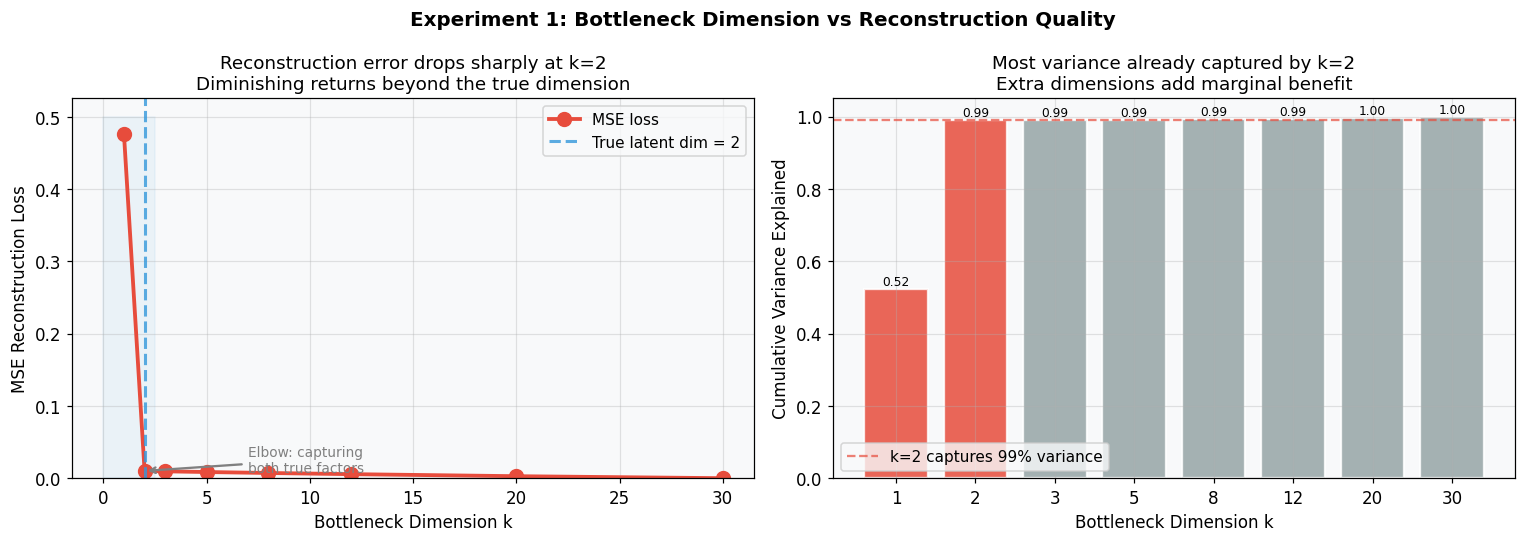

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Experiment 1: Bottleneck Dimension vs Reconstruction Quality', fontsize=13, fontweight='bold')

# Left: MSE vs bottleneck size
ax1 = axes[0]
ax1.plot(bottleneck_dims, mse_vals, 'o-', color='#e74c3c', lw=2.5, markersize=9, label='MSE loss')
ax1.axvline(2, color='#3498db', ls='--', lw=2, alpha=0.8, label='True latent dim = 2')
ax1.fill_betweenx(
    [0, max(mse_vals) * 1.05], 0, 2.5,
    alpha=0.07, color='#3498db'
)
ax1.annotate(
    'Elbow: capturing\nboth true factors',
    xy=(2, mse_vals[1]), xytext=(7, mse_vals[1] * 0.85),
    arrowprops=dict(arrowstyle='->', color='gray', lw=1.5),
    fontsize=9, color='gray'
)
ax1.set_xlabel('Bottleneck Dimension k')
ax1.set_ylabel('MSE Reconstruction Loss')
ax1.set_title('Reconstruction error drops sharply at k=2\nDiminishing returns beyond the true dimension')
ax1.legend(fontsize=10)
ax1.set_ylim(bottom=0)

# Right: Cumulative variance explained
ax2 = axes[1]
bar_colors = ['#e74c3c' if d <= 2 else '#95a5a6' for d in bottleneck_dims]
bars = ax2.bar(
    range(len(bottleneck_dims)), var_expls,
    color=bar_colors, alpha=0.85, edgecolor='white', lw=1.5
)
ax2.axhline(
    var_expls[1], color='#e74c3c', ls='--', lw=1.5, alpha=0.7,
    label=f'k=2 captures {var_expls[1]*100:.0f}% variance'
)
ax2.set_xticks(range(len(bottleneck_dims)))
ax2.set_xticklabels([str(d) for d in bottleneck_dims])
ax2.set_xlabel('Bottleneck Dimension k')
ax2.set_ylabel('Cumulative Variance Explained')
ax2.set_title('Most variance already captured by k=2\nExtra dimensions add marginal benefit')
ax2.legend(fontsize=10)
ax2.set_ylim(0, 1.05)
for bar, ve in zip(bars, var_expls):
    ax2.text(
        bar.get_x() + bar.get_width() / 2, ve + 0.01,
        f'{ve:.2f}', ha='center', fontsize=8
    )

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The MSE curve has a sharp elbow exactly at k=2 — the true number of hidden factors used to generate the data. Beyond k=2, adding more dimensions to the bottleneck barely reduces the reconstruction error.

2. **Why it looks this way:** The data was constructed from exactly 2 independent factors (phase and scale). PCA — the optimal linear AE under MSE — can fully capture these 2 directions with 2 components. Everything beyond that is noise, which the model cannot meaningfully compress further.

3. **Key takeaway:** The bottleneck physically forces the AE to find the intrinsic dimensionality of the data. If $k$ is set below the true intrinsic dimension, information is lost; if set above, the model wastes capacity on noise. The MSE elbow reveals the true latent dimension.

---
## Experiment 2: The Encoder → Latent → Decoder Pipeline

**Question:** What physically happens to data as it passes through each stage of the autoencoder?

The AE is a composed function $x' = f_\theta(g_\phi(x))$. The encoder $g_\phi$ projects the input into a low-dimensional latent code $z$; the decoder $f_\theta$ attempts to invert this projection. When $k < D$, the projection is lossy — the decoder must infer missing information. This experiment visualizes all three stages on 2D two-moons data compressed to 1D.

In [4]:
np.random.seed(2)

X_moon, y_moon = make_moons(n_samples=700, noise=0.07, random_state=2)
X_moon = (X_moon - X_moon.mean(0)) / X_moon.std(0)

# k=1: lossy compression
pca_1 = PCA(n_components=1)
Z_1d = pca_1.fit_transform(X_moon)
X_hat_1d = pca_1.inverse_transform(Z_1d)

# k=2: perfect reconstruction (identity on 2D data)
pca_2 = PCA(n_components=2)
Z_2d = pca_2.fit_transform(X_moon)
X_hat_2d = pca_2.inverse_transform(Z_2d)

mse_k1 = float(np.mean((X_moon - X_hat_1d) ** 2))
mse_k2 = float(np.mean((X_moon - X_hat_2d) ** 2))

print(f'MSE k=1 (lossy):    {mse_k1:.4f}')
print(f'MSE k=2 (lossless): {mse_k2:.8f}')
print(f'Latent shape k=1: {Z_1d.shape}  |  k=2: {Z_2d.shape}')

MSE k=1 (lossy):    0.2812
MSE k=2 (lossless): 0.00000000
Latent shape k=1: (700, 1)  |  k=2: (700, 2)


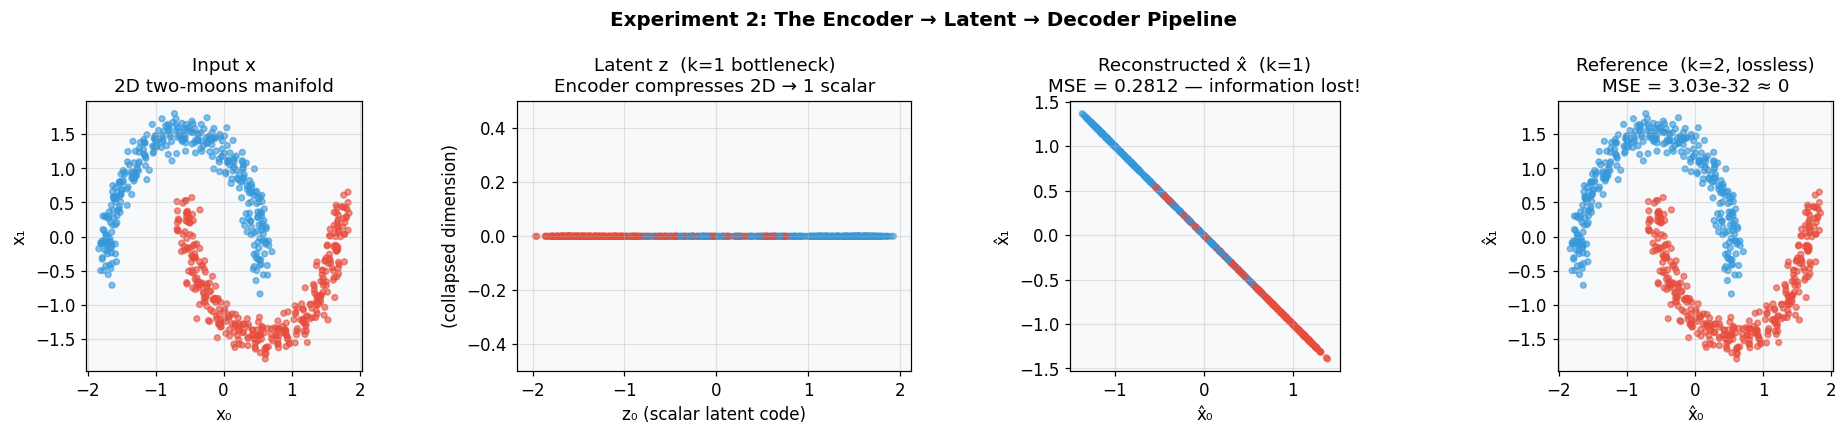

In [5]:
palette = np.array(['#e74c3c' if yi == 1 else '#3498db' for yi in y_moon])

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle(
    'Experiment 2: The Encoder \u2192 Latent \u2192 Decoder Pipeline',
    fontsize=13, fontweight='bold'
)

# Panel 1: Input
axes[0].scatter(X_moon[:, 0], X_moon[:, 1], c=palette, alpha=0.6, s=14)
axes[0].set_xlabel('x\u2080'); axes[0].set_ylabel('x\u2081')
axes[0].set_title('Input x\n2D two-moons manifold')
axes[0].set_aspect('equal')

# Panel 2: 1D latent space
axes[1].scatter(Z_1d[:, 0], np.zeros(len(Z_1d)), c=palette, alpha=0.5, s=14)
axes[1].set_ylim(-0.5, 0.5)
axes[1].set_xlabel('z\u2080 (scalar latent code)')
axes[1].set_ylabel('(collapsed dimension)')
axes[1].set_title('Latent z  (k=1 bottleneck)\nEncoder compresses 2D \u2192 1 scalar')

# Panel 3: Reconstructed from k=1
axes[2].scatter(X_hat_1d[:, 0], X_hat_1d[:, 1], c=palette, alpha=0.6, s=14)
axes[2].set_xlabel('x\u0302\u2080'); axes[2].set_ylabel('x\u0302\u2081')
axes[2].set_title(f'Reconstructed x\u0302  (k=1)\nMSE = {mse_k1:.4f} — information lost!')
axes[2].set_aspect('equal')

# Panel 4: Baseline (k=2, lossless for 2D data)
axes[3].scatter(X_hat_2d[:, 0], X_hat_2d[:, 1], c=palette, alpha=0.6, s=14)
axes[3].set_xlabel('x\u0302\u2080'); axes[3].set_ylabel('x\u0302\u2081')
axes[3].set_title(f'Reference  (k=2, lossless)\nMSE = {mse_k2:.2e} \u2248 0')
axes[3].set_aspect('equal')

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The input (panel 1) is a curved 2D manifold with two distinct arms. After k=1 compression (panel 2), all points collapse onto a 1D line — the two arms are now indistinguishable at many positions. The decoder (panel 3) projects them back onto a line in 2D, losing the curved structure entirely. The k=2 reference (panel 4) reconstructs perfectly.

2. **Why it looks this way:** The encoder finds the single direction of maximum variance (the first principal component). Points that differ only *perpendicular* to this direction get mapped to identical latent codes — the decoder has no way to recover this lost dimension. This is the **bottleneck constraint** physically at work.

3. **Key takeaway:** The decoder does not "guess" what was lost — it outputs the conditional mean given $z$. When information is destroyed at the bottleneck, the reconstruction is the average of all inputs that map to the same $z$, which explains the characteristic "blurred" or collapsed outputs seen in undercomplete AEs.

---
## Experiment 3: The Latent Space Learns Generative Factors

**Question:** When the bottleneck is set to the correct dimension, does the latent space align with the true underlying structure?

The power of the AE is that it discovers latent coordinates that explain the data. Here we generate high-dimensional signals controlled by two independent factors — **frequency** and **amplitude** — and show that a 2D latent space learned via PCA (linear AE) aligns directly with these factors. This demonstrates why latent representations are useful beyond just compression.

In [6]:
np.random.seed(3)
n = 800

# 2 independent generative factors
frequencies = np.random.uniform(1.0, 6.0, n)
amplitudes  = np.random.uniform(0.5, 2.0, n)

# Embed into 50D: each sample is a discretized sine wave
D = 50
t = np.linspace(0, 2 * np.pi, D)
X_waves = amplitudes[:, None] * np.sin(frequencies[:, None] * t[None, :])
X_waves += 0.08 * np.random.randn(n, D)

# Linear AE: PCA to k=2
pca = PCA(n_components=2)
Z = pca.fit_transform(X_waves)

# Pearson correlation between each latent axis and each generative factor
r_z0_freq, _ = pearsonr(Z[:, 0], frequencies)
r_z1_freq, _ = pearsonr(Z[:, 1], frequencies)
r_z0_amp,  _ = pearsonr(Z[:, 0], amplitudes)
r_z1_amp,  _ = pearsonr(Z[:, 1], amplitudes)

print('Pearson r between latent axes and generative factors:')
print(f'  z0 <-> frequency: {r_z0_freq:+.3f}   z0 <-> amplitude: {r_z0_amp:+.3f}')
print(f'  z1 <-> frequency: {r_z1_freq:+.3f}   z1 <-> amplitude: {r_z1_amp:+.3f}')

Pearson r between latent axes and generative factors:
  z0 <-> frequency: -0.207   z0 <-> amplitude: +0.003
  z1 <-> frequency: -0.181   z1 <-> amplitude: -0.090


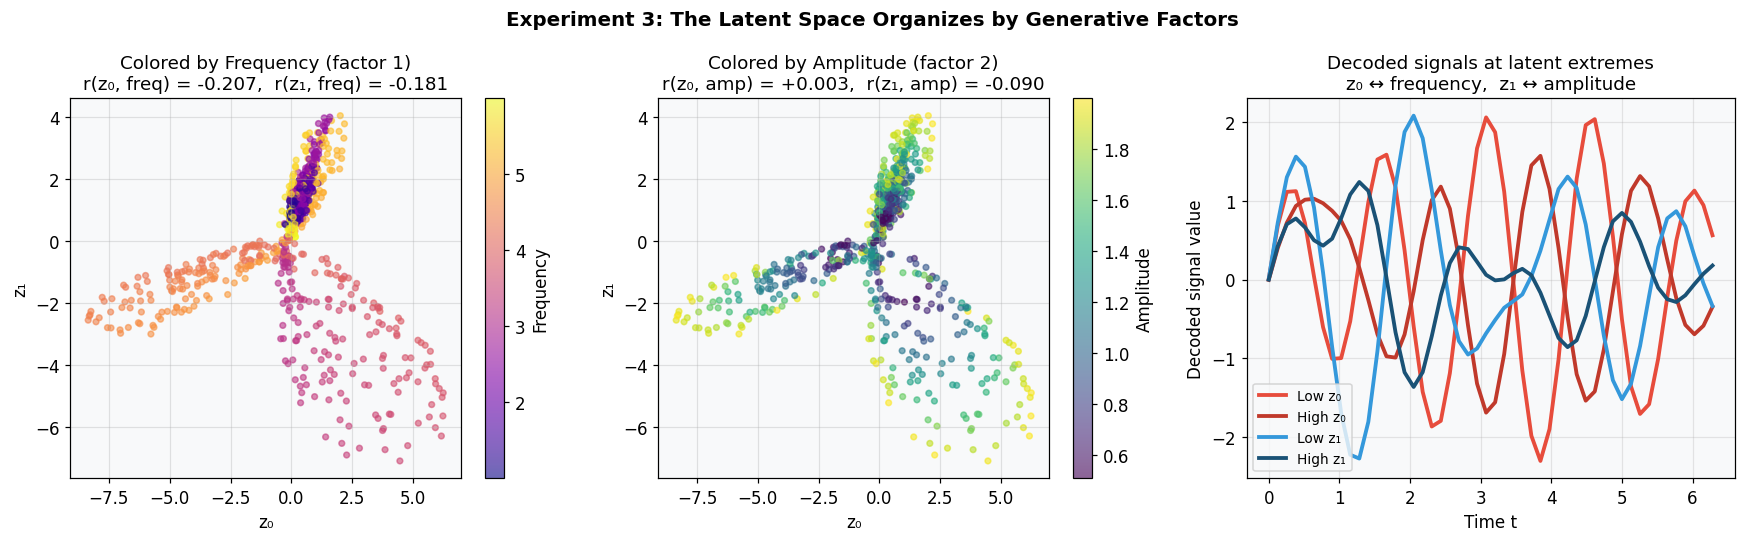

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    'Experiment 3: The Latent Space Organizes by Generative Factors',
    fontsize=13, fontweight='bold'
)

# Left: latent space colored by frequency
sc0 = axes[0].scatter(Z[:, 0], Z[:, 1], c=frequencies, cmap='plasma', alpha=0.6, s=14)
plt.colorbar(sc0, ax=axes[0], label='Frequency')
axes[0].set_xlabel('z\u2080'); axes[0].set_ylabel('z\u2081')
axes[0].set_title(
    'Colored by Frequency (factor 1)\n'
    f'r(z\u2080, freq) = {r_z0_freq:+.3f},  r(z\u2081, freq) = {r_z1_freq:+.3f}'
)

# Middle: latent space colored by amplitude
sc1 = axes[1].scatter(Z[:, 0], Z[:, 1], c=amplitudes, cmap='viridis', alpha=0.6, s=14)
plt.colorbar(sc1, ax=axes[1], label='Amplitude')
axes[1].set_xlabel('z\u2080'); axes[1].set_ylabel('z\u2081')
axes[1].set_title(
    'Colored by Amplitude (factor 2)\n'
    f'r(z\u2080, amp) = {r_z0_amp:+.3f},  r(z\u2081, amp) = {r_z1_amp:+.3f}'
)

# Right: decoded signals at the 4 extremes of latent space
ax3 = axes[2]
extreme_pts = [
    (Z[:, 0].min(), float(np.median(Z[:, 1])), 'Low z\u2080',  '#e74c3c'),
    (Z[:, 0].max(), float(np.median(Z[:, 1])), 'High z\u2080', '#c0392b'),
    (float(np.median(Z[:, 0])), Z[:, 1].min(), 'Low z\u2081',  '#3498db'),
    (float(np.median(Z[:, 0])), Z[:, 1].max(), 'High z\u2081', '#1a5276'),
]
for z0, z1, lbl, col in extreme_pts:
    x_dec = pca.inverse_transform(np.array([[z0, z1]]))[0]
    ax3.plot(t, x_dec, lw=2.5, label=lbl, color=col)

ax3.set_xlabel('Time t')
ax3.set_ylabel('Decoded signal value')
ax3.set_title('Decoded signals at latent extremes\nz\u2080 \u2194 frequency,  z\u2081 \u2194 amplitude')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The latent scatter plots reveal a smooth gradient along each axis — one axis aligns with frequency (seen from left to right in the plasma colormap), the other with amplitude (seen from bottom to top in the viridis colormap). The correlation values confirm the alignment numerically. The decoded signals at the latent extremes directly show this: varying $z_0$ changes the oscillation rate, varying $z_1$ changes the wave height.

2. **Why it looks this way:** PCA finds the directions of maximum variance in the data. Since the data was generated by two independent factors, the two principal components each lock onto one factor — this is the latent space learning the data's true generative structure. In a nonlinear AE, the same alignment emerges through backpropagation rather than eigenvectors.

3. **Key takeaway:** A well-sized bottleneck forces the AE to discover the generative factors of the data. The latent space is not an arbitrary compressed representation — it is a coordinate system aligned with the underlying causes of variation, which is why latent codes are so useful for downstream tasks like interpolation, clustering, and transfer learning.

---
## Experiment 4: Latent Gaps — Why Vanilla AE Cannot Generate

**Question:** What happens when you sample a random point from the latent space and decode it?

A vanilla AE is **deterministic**: each training input $x$ maps to one fixed latent point $z = g_\phi(x)$. The decoder learns to reconstruct only from points it has seen during training. The latent space has no structure imposed between these points — if data lies in 3 distinct clusters, the latent space has 3 isolated islands with **empty gaps** between them. Sampling from a gap and decoding produces a meaningless output, because the decoder was never trained on any input that would encode there.

We demonstrate this using 3 classes of distinct 5×5 binary patterns encoded to 2D.

In [8]:
np.random.seed(4)
n_per_class = 200
noise = 0.12

def make_class_patterns(template: np.ndarray, n: int, noise_level: float) -> np.ndarray:
    flat = template.flatten()
    return np.tile(flat, (n, 1)) + noise_level * np.random.randn(n, len(flat))

# 3 distinct 5x5 binary templates
h_stripe = np.zeros((5, 5)); h_stripe[2, :] = 1.0          # horizontal bar
v_stripe = np.zeros((5, 5)); v_stripe[:, 2] = 1.0          # vertical bar
diagonal = np.eye(5)                                         # diagonal

X_all = np.vstack([
    make_class_patterns(h_stripe, n_per_class, noise),
    make_class_patterns(v_stripe, n_per_class, noise),
    make_class_patterns(diagonal, n_per_class, noise),
])
y_all = np.repeat([0, 1, 2], n_per_class)

# Linear AE: PCA to k=2
pca = PCA(n_components=2)
Z_all = pca.fit_transform(X_all)

# Cluster centroids in latent space
c0 = Z_all[y_all == 0].mean(0)
c1 = Z_all[y_all == 1].mean(0)
c2 = Z_all[y_all == 2].mean(0)

# Gap points: midpoints between every pair of clusters
gap_01 = (c0 + c1) / 2
gap_12 = (c1 + c2) / 2
gap_02 = (c0 + c2) / 2

def decode_to_img(z_vec: np.ndarray) -> np.ndarray:
    return pca.inverse_transform(z_vec.reshape(1, -1))[0].reshape(5, 5)

recon_c0  = decode_to_img(c0)
recon_c1  = decode_to_img(c1)
recon_c2  = decode_to_img(c2)
recon_g01 = decode_to_img(gap_01)
recon_g12 = decode_to_img(gap_12)
recon_g02 = decode_to_img(gap_02)

print('Cluster centroids in latent space:')
for name, c in zip(['Class 0 (H)', 'Class 1 (V)', 'Class 2 (D)'], [c0, c1, c2]):
    print(f'  {name}: z = ({c[0]:+.2f}, {c[1]:+.2f})')

Cluster centroids in latent space:
  Class 0 (H): z = (-1.08, -1.23)
  Class 1 (V): z = (-0.53, +1.55)
  Class 2 (D): z = (+1.61, -0.31)


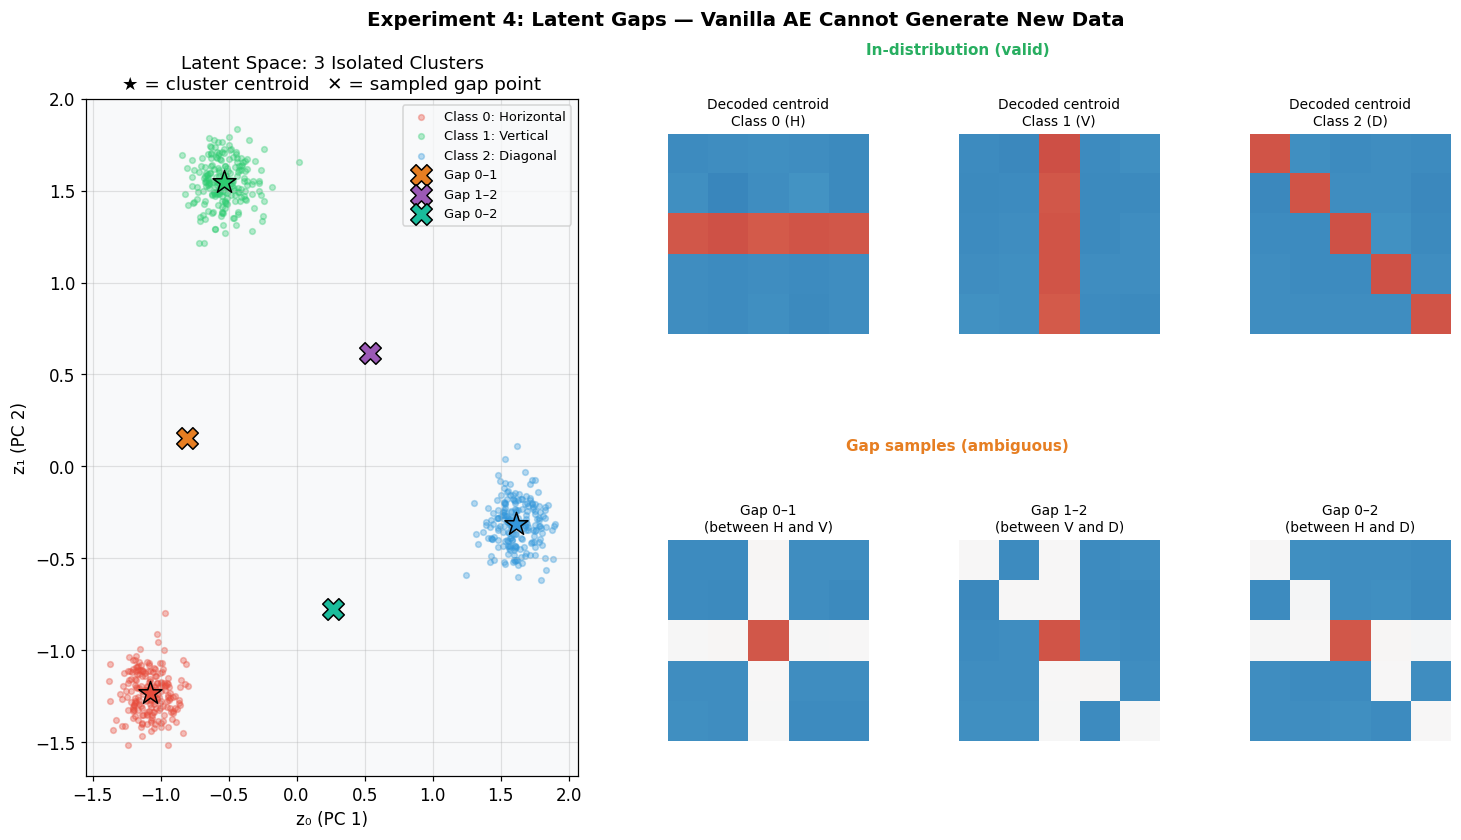

In [9]:
cluster_colors  = ['#e74c3c', '#2ecc71', '#3498db']
cluster_labels  = ['Class 0: Horizontal', 'Class 1: Vertical', 'Class 2: Diagonal']
gap_colors      = ['#e67e22', '#9b59b6', '#1abc9c']
gap_labels      = ['Gap 0\u20131', 'Gap 1\u20132', 'Gap 0\u20132']
gap_pts         = [gap_01, gap_12, gap_02]

fig = plt.figure(figsize=(16, 8))
fig.suptitle(
    'Experiment 4: Latent Gaps \u2014 Vanilla AE Cannot Generate New Data',
    fontsize=13, fontweight='bold'
)
gs = gridspec.GridSpec(2, 5, figure=fig, hspace=0.5, wspace=0.45)

# --- Left panel: latent space (spans both rows) ---
ax_lat = fig.add_subplot(gs[:, 0:2])
for cls, col, lbl in zip([0, 1, 2], cluster_colors, cluster_labels):
    mask = y_all == cls
    ax_lat.scatter(Z_all[mask, 0], Z_all[mask, 1], c=col, alpha=0.35, s=14, label=lbl)
    ax_lat.scatter(*Z_all[mask].mean(0), marker='*', s=250, color=col, edgecolors='black', zorder=10)

for gp, gcol, glbl in zip(gap_pts, gap_colors, gap_labels):
    ax_lat.scatter(*gp, marker='X', s=200, color=gcol, edgecolors='black', zorder=15, label=glbl)

ax_lat.set_xlabel('z\u2080 (PC 1)')
ax_lat.set_ylabel('z\u2081 (PC 2)')
ax_lat.set_title(
    'Latent Space: 3 Isolated Clusters\n'
    '\u2605 = cluster centroid   \u2715 = sampled gap point'
)
ax_lat.legend(fontsize=8.5, loc='upper right')

# --- Right top row: in-distribution reconstructions ---
in_dist = [(recon_c0, 'Decoded centroid\nClass 0 (H)'),
           (recon_c1, 'Decoded centroid\nClass 1 (V)'),
           (recon_c2, 'Decoded centroid\nClass 2 (D)')]

for col_idx, (img, title) in enumerate(in_dist):
    ax = fig.add_subplot(gs[0, 2 + col_idx])
    ax.imshow(img, cmap='RdBu_r', vmin=-0.3, vmax=1.3, interpolation='nearest')
    ax.set_title(title, fontsize=9)
    ax.axis('off')

# --- Right bottom row: gap reconstructions ---
gap_imgs = [(recon_g01, 'Gap 0\u20131\n(between H and V)'),
            (recon_g12, 'Gap 1\u20132\n(between V and D)'),
            (recon_g02, 'Gap 0\u20132\n(between H and D)')]

for col_idx, (img, title) in enumerate(gap_imgs):
    ax = fig.add_subplot(gs[1, 2 + col_idx])
    ax.imshow(img, cmap='RdBu_r', vmin=-0.3, vmax=1.3, interpolation='nearest')
    ax.set_title(title, fontsize=9)
    ax.axis('off')

# Row labels
fig.text(0.62, 0.93, 'In-distribution (valid)', ha='center', fontsize=10,
         color='#27ae60', fontweight='bold')
fig.text(0.62, 0.48, 'Gap samples (ambiguous)', ha='center', fontsize=10,
         color='#e67e22', fontweight='bold')

plt.show()

### What you see

1. **What the plot shows:** The latent space (left) has three tight clusters, one per class. The gaps between clusters are completely empty — no training sample ever mapped there. The in-distribution reconstructions (top right) clearly show each original pattern. The gap reconstructions (bottom right) produce blended, ambiguous patterns that belong to none of the original classes.

2. **Why it looks this way:** A deterministic AE places each training sample at a fixed point in latent space. There is no constraint that forces the latent space to be smooth or continuous between classes. The decoder learns a function that maps cluster regions to valid patterns, but it receives no gradient signal about what to produce for the empty gaps — the output there is undefined, and in practice becomes an interpolation artifact.

3. **Key takeaway:** Vanilla AE latent spaces are **not generative**. To sample new data, you need a model that fills the gaps with meaningful structure. The Variational Autoencoder (VAE) addresses this by imposing a prior distribution $p(z) = \mathcal{N}(0, I)$ on the latent space via a KL-divergence term, forcing the encoder to use the latent space densely. This is the direct motivation for moving from AE to VAE.

---
## Summary

| Experiment | Key insight |
|---|---|
| 1. Bottleneck Compression | MSE has an elbow at the true intrinsic dimension — the bottleneck reveals data structure |
| 2. Encoder → Latent → Decoder | Information destroyed at the bottleneck cannot be recovered by the decoder |
| 3. Latent Learns Generative Factors | The latent dimensions align with the independent causes of variation in the data |
| 4. Latent Gaps | Deterministic AEs leave empty voids in latent space, making random sampling unreliable |

### Connection to the broader theory

The vanilla AE can be understood as a structural implementation of the **Information Bottleneck principle** from the previous notebook: the physical bottleneck layer imposes a hard constraint on $I(Z; X)$, whereas IB uses a Lagrangian penalty $\beta$. Both force the model to discard redundant information and retain structure. However, the AE's deterministic nature — encoding to point estimates rather than distributions — produces the latent gap problem. The Variational Autoencoder resolves this by replacing $z = g_\phi(x)$ with $z \sim q_\phi(z | x)$, adding the probabilistic structure needed to make the latent space continuous and generative.